Proporção da Variável Resposta (Purchased):
Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64


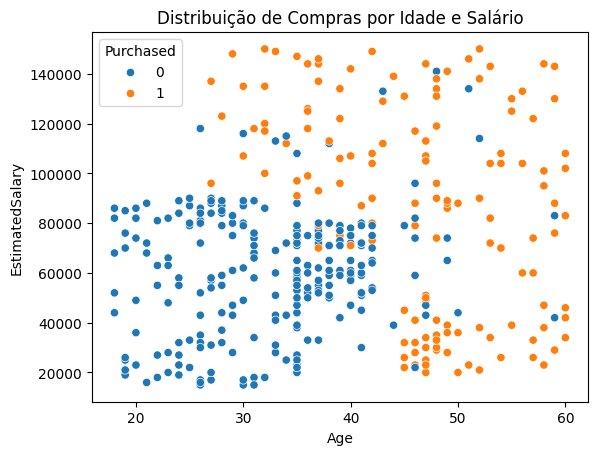

In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_suv = pd.read_csv('SUV_Network_Ads (3).csv')

print("Proporção da Variável Resposta (Purchased):")
print(df_suv['Purchased'].value_counts(normalize=True))

sns.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df_suv)
plt.title('Distribuição de Compras por Idade e Salário')
plt.show()

#### Análise Descritiva

A amostra tem 400 pessoas (64,2% não compraram o SUV; 35,8% compraram). 

Podemos notar que a compra é impulsionada por dois fatores: ou o usuário tem um salário muito alto (acima de R$ 90.000, válido até para os mais jovens), ou o usuário tem mais de 42 anos (onde a compra ocorre independentemente do salário).

In [3]:
df_suv['Salary_Norm'] = df_suv['EstimatedSalary'] / 1000 

modelo_suv = smf.logit('Purchased ~ Age + Salary_Norm', data=df_suv).fit()

Optimization terminated successfully.
         Current function value: 0.346314
         Iterations 8


Aplicada uma regressão logística, dividindo o salário por 1.000 (Salary_Norm) para melhor ajuste.

In [4]:
X_vif = df_suv[['Age', 'Salary_Norm']]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variável"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n--- Validação: Fator de Inflação da Variância (VIF) ---")
print(vif_data)


--- Validação: Fator de Inflação da Variância (VIF) ---
      Variável        VIF
0        const  16.209027
1          Age   1.024694
2  Salary_Norm   1.024694


O pressuposto de ausência de multicolinearidade foi atendido. 

O teste VIF (Fator de Inflação da Variância) resultou em 1.024 para ambas as variáveis, valor abaixo do limite crítico de 5, provando que Idade e Salário são independentes entre si.

In [5]:
print("\n--- Sumário do Modelo ---")
print(modelo_suv.summary())


--- Sumário do Modelo ---
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      397
Method:                           MLE   Df Model:                            2
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.4688
Time:                        19:59:24   Log-Likelihood:                -138.53
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 7.995e-54
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -12.4340      1.300     -9.566      0.000     -14.982      -9.886
Age             0.2335      0.026      9.013      0.000       0.183       0.284
Salary_Norm     0.035

Modelo é estatisticamente válido

As duas variáveis preditoras (Idade e Salário) são significativas, ambas apresentando p-valor individual igual a 0.000.


In [6]:
print("\n--- Razão de Chances (Odds Ratio) ---")
odds_ratios = np.exp(modelo_suv.params)
print(odds_ratios)


--- Razão de Chances (Odds Ratio) ---
Intercept      0.000004
Age            1.262999
Salary_Norm    1.036553
dtype: float64


Idade (OR = 1.263): Para cada 1 ano a mais de idade, as chances de comprar o SUV aumentam em 26,3% (mantendo o salário constante).

Salário (OR = 1.036): Para cada 1000 a mais no salário, as chances de comprar o SUV aumentam em 3,6% (mantendo a idade constante).